In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import argparse
import numpy as np
import random
import scipy
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.stats import kendalltau
import pandas as pd

In [2]:
edge=np.genfromtxt("./opsahl-usairport/out.opsahl-usairport",delimiter=" ",
                                        dtype=int)
edge=edge-1
#print(edge)
edges=edge[:,:2]
#print(edges)
#print(edges.max())
adj = sp.coo_matrix((np.ones(edges.shape[0]), (edges[:, 0], edges[:, 1])),
                        shape=(1574, 1574))
adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)
adj_usa = torch.FloatTensor(np.array(adj.todense()))
list_usa=list(range(1574))

In [3]:
def min_max_normalization(tensor):
    # 找出数组的最小值和最大值
    min_val = torch.min(tensor)
    max_val = torch.max(tensor)

    # 进行最小 - 最大标准化
    normalized_tensor = (tensor - min_val) / (max_val - min_val)
    return normalized_tensor
# node_feature_BA = min_max_normalization(node_feature_BA)
# node_feature_BA1 = min_max_normalization(node_feature_BA1)

In [4]:
class GNN(torch.nn.Module):
    def __init__(self,input_feature,output_feature):
        super(GNN,self).__init__()
        self.w = nn.Parameter(torch.empty(size=(input_feature,output_feature)))
        self.a= nn.Parameter(torch.empty(size=(1,output_feature)))
        self.sigmod=torch.nn.Sigmoid()
        self.reset_parameters()
    def reset_parameters(self):
        #nn.init.xavier_uniform_(self.w.data,gain=1.414)
        #nn.init.xavier_uniform_(self.a.data,gain=1.414)
        for param in self.parameters():
             nn.init.xavier_uniform_(param)
        
    def forward(self,x,adj):
        adj=torch.Tensor(adj.numpy()+np.identity(adj.shape[0]))
        # adj=torch.FloatTensor(normalize_adj(sp.csr_matrix(adj)+ sp.eye(adj.shape[0])).todense())
        x=torch.mm(adj,x)
        x=torch.mm(x,self.w)
        x=x.add(self.a)
        x=torch.relu(x)
        return x


class CGNN(torch.nn.Module):
    def __init__(self):
        super(CGNN,self).__init__()
        self.layer2=GNN(48,6)
        self.layer3=GNN(6,12)
        # self.fc1=torch.nn.Linear(6,12)
        self.fc1=torch.nn.Linear(12,1)
        # self.fc2=torch.nn.Linear(24,1)
        
        
       
     
    
    
    def forward(self,x,adj,target_nodes):
        #x=self.layer1(x)
        # x=torch.cat([x1,x],dim=-1)
        # x=0.5*x+0.5*x1
        x=self.layer2(x,adj)
        x=self.layer3(x,adj)
       # x=self.layer4(x,adj)
        
        x=x[target_nodes]
        
        x=self.fc1(x.view(x.size(0),-1))
        x=torch.relu(x)
        # x=self.fc2(x)
        # x=torch.relu(x)
        x=x.flatten()
        
        return x

In [ ]:
import optuna
import time
import numpy as np
import torch
import torch.optim as optim
from scipy.stats import kendalltau


def objective(trial):
    # 1. 定义超参数搜索空间
    learning_rate = trial.suggest_float(
        "learning_rate", 
        low=0.001, 
        high=0.01, 
        step=0.001  # 学习率：0.001-0.01，步长0.001
    )
    epochs = trial.suggest_int(
        "epochs", 
        low=100, 
        high=2000, # 训练次数：100-1000之间的任意整数
        step=100
    )
    epoch_1=trial.suggest_int(
        "epoch_1", 
        low=100, 
        high=600, # 训练次数：100-1000之间的任意整数
        step=100
    )
    learning_rate1 = trial.suggest_categorical(
        "learning_rate1", 
        [0.01,0.001,0.005]  # 仅允许这三个候选值
    )
    # 2. 初始化模型和优化器
    lable_usa=np.load("lable/lable_usa.npy")
    lable_usa_t=torch.tensor(lable_usa).float()
    node_feature_usa=torch.load("EC做损失的特征向量/node_feature_usa_LSTM_EC_"+str(learning_rate1)+"_"+str(epoch_1)+".pt")
    node_feature_usa = min_max_normalization(node_feature_usa)
    # 2. 初始化模型和优化器
    random.seed(17)
    np.random.seed(17)
    torch.manual_seed(17)
    
# 设置聚类数量
    k = 6
    X = node_feature_usa.detach().numpy()

# 执行 KMeans 聚类
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
    cluster_nodes = {i: [] for i in range(k)}
    for idx, label in enumerate(labels):
        cluster_nodes[label].append(idx)
#选择训练集的节点
    n_nodes = node_feature_usa.shape[0]

# 1. 随机采样 5% 的节点索引
    # 1. 随机采样 5% 的节点索引
    num_train = int(0.05 * n_nodes)+1
    num_pinggu = int(0.05 * n_nodes)+1

    train_idx=[]
    while len(train_idx) < num_train:
        for i in range(k):
            if cluster_nodes[i]:  # 确保当前簇中还有节点可取
                node = random.choice(cluster_nodes[i])  # 随机选一个
                train_idx.append(node)
                cluster_nodes[i].remove(node)
                if len(train_idx) >= num_train:
                    break

    pinggu_idx=[]
    while len(pinggu_idx) < num_train:
        for i in range(k):
            if cluster_nodes[i]:  # 确保当前簇中还有节点可取
                node = random.choice(cluster_nodes[i])  # 随机选一个
                pinggu_idx.append(node)
                cluster_nodes[i].remove(node)
                if len(pinggu_idx) >= num_train:
                    break

# 2. 构造训练集（只选取部分节点特征）
    train_usa = node_feature_usa[train_idx]
    train_usa_lable = lable_usa_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
    
    pinggu_usa = node_feature_usa[pinggu_idx]
    pinggu_usa_lable = lable_usa_t[pinggu_idx]



    random.seed(17)
    np.random.seed(17)
    torch.manual_seed(17)
    model = CGNN()  # 实例化你的模型

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=5e-4  # 保持权重衰减不变
    )
    
    # 3. 训练模型
    for epoch in range(epochs):
        # 训练过程（复用你的train函数逻辑）
        model.train()
        output = model(node_feature_usa.data, adj_usa, train_idx)
        loss_train = torch.nn.functional.mse_loss(output, train_usa_lable)
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        # 每100轮打印一次中间结果（可选）
        if (epoch + 1) % 100 == 0:
            print(f"当前参数组合: 学习率={learning_rate}, 训练次数={epochs}, 轮次={epoch+1}, 训练损失={loss_train.item():.4f}")
    
    # 4. 在验证集上评估RMSE
    model.eval()
    with torch.no_grad():  # 关闭梯度计算，节省内存
        pinggu_pre = model(node_feature_usa.data, adj_usa, pinggu_idx)
        # 转换为numpy数组计算RMSE
        pinggu_pre_np = pinggu_pre.detach().numpy()
        pinggu_true=pinggu_usa_lable.detach().numpy()
        # print(kendalltau(pinggu_pre_np,pinggu_pre_np))
        rmse=kendalltau(pinggu_pre_np,pinggu_true).statistic
        # rmse = np.sqrt(np.mean((pinggu_true - pinggu_pre_np) **2))
    
    # 5. 返回需要最小化的RMSE（Optuna会寻找最小RMSE对应的参数）
    return rmse

if __name__ == '__main__':
    # 创建优化实例，方向为"最小化"RMSE
    study = optuna.create_study(direction="maximize")
    # 尝试20组参数组合
    study.optimize(objective, n_trials=300)
    
    # 输出最优结果
    print("\n优化完成！")
    print(f"最佳参数组合: {study.best_params}")
    print(f"最小RMSE: {study.best_value:.4f}")
    print(f"最佳试验编号: {study.best_trial.number}")

[I 2025-09-17 23:15:27,125] A new study created in memory with name: no-name-1dd0e1b3-7b8f-4a0d-b192-76ac908901e7
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=100, 训练损失=48.8255
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=200, 训练损失=45.9592
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=300, 训练损失=43.8630
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=400, 训练损失=42.7196
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=500, 训练损失=41.7280
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=600, 训练损失=40.8237
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=700, 训练损失=39.8490
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=800, 训练损失=37.3816
当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=900, 训练损失=35.3193


[I 2025-09-17 23:16:09,146] Trial 0 finished with value: 0.8301948051948052 and parameters: {'learning_rate': 0.009000000000000001, 'epochs': 1000, 'epoch_1': 400, 'learning_rate1': 0.01}. Best is trial 0 with value: 0.8301948051948052.


当前参数组合: 学习率=0.009000000000000001, 训练次数=1000, 轮次=1000, 训练损失=33.4697


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


...

当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=100, 训练损失=91.0794
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=200, 训练损失=80.4097
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=300, 训练损失=72.6104
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=400, 训练损失=68.8459
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=500, 训练损失=59.8991
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=600, 训练损失=58.3095
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=700, 训练损失=57.6210
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=800, 训练损失=57.2114
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=900, 训练损失=56.7508
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1000, 训练损失=56.4022
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1100, 训练损失=55.9026
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1200, 训练损失=55.5790
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1300, 训练损失=55.2464
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1400, 训练损失=54.9608
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1500, 训练损失=54.0984
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1600, 训练损失=53.3165
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1700, 训练损失=46.1176
当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1800, 训练损失=45.2388


[I 2025-09-18 03:16:27,488] Trial 220 finished with value: 0.8819614619897186 and parameters: {'learning_rate': 0.003, 'epochs': 1900, 'epoch_1': 100, 'learning_rate1': 0.005}. Best is trial 137 with value: 0.9066407959776489.


当前参数组合: 学习率=0.003, 训练次数=1900, 轮次=1900, 训练损失=45.5169


C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


当前参数组合: 学习率=0.004, 训练次数=1900, 轮次=100, 训练损失=313.6236
当前参数组合: 学习率=0.004, 训练次数=1900, 轮次=200, 训练损失=86.1625
当前参数组合: 学习率=0.004, 训练次数=1900, 轮次=300, 训练损失=71.9497
当前参数组合: 学习率=0.004, 训练次数=1900, 轮次=400, 训练损失=66.8565
当前参数组合: 学习率=0.004, 训练次数=1900, 轮次=500, 训练损失=63.9221


In [9]:
node_feature_usa=torch.load("EC做损失的特征向量/node_feature_usa_LSTM_EC_0.005_100.pt")
node_feature_usa = min_max_normalization(node_feature_usa)

In [11]:
lable_usa=np.load("lable/lable_usa.npy")
lable_usa_t=torch.tensor(lable_usa).float()

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

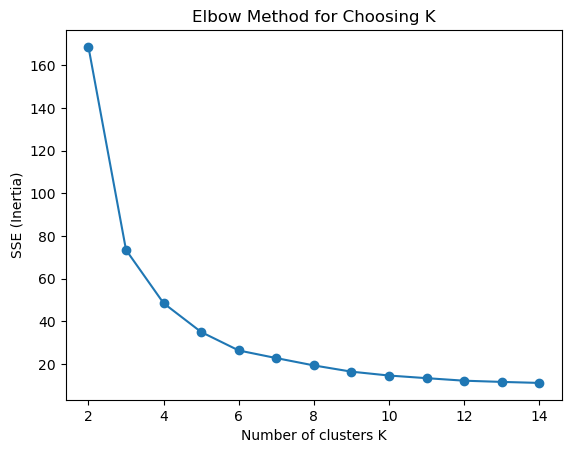

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 假设你的特征矩阵叫 node_feature_vidal
X = node_feature_usa.detach().numpy()

# 1. 肘部法则（Elbow Method）
sse = []
k_list = range(2, 15)  # 尝试K从2到14
for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_就是SSE

plt.figure()
plt.plot(k_list, sse, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method for Choosing K')
plt.show()

In [15]:
import numpy as np
from sklearn.cluster import KMeans
# 假设 node_feature_usa 是你的节点特征矩阵，形状是 (num_nodes, feature_dim)
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
    
# 设置聚类数量
k = 6
X = node_feature_usa.detach().numpy()

# 执行 KMeans 聚类
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X)

# labels 是每个节点对应的聚类类别，比如 labels[i] 是第i个节点所属的簇编号

# 将节点按簇分类整理
cluster_nodes = {i: [] for i in range(k)}
for idx, label in enumerate(labels):
    cluster_nodes[label].append(idx)
#选择训练集的节点
n_nodes = node_feature_usa.shape[0]

# 1. 随机采样 5% 的节点索引
num_train = int(0.05 * n_nodes)+1

train_idx=[]
while len(train_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            train_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(train_idx) >= num_train:
                break

pinggu_idx=[]
while len(pinggu_idx) < num_train:
    for i in range(k):
        if cluster_nodes[i]:  # 确保当前簇中还有节点可取
            node = random.choice(cluster_nodes[i])  # 随机选一个
            pinggu_idx.append(node)
            cluster_nodes[i].remove(node)
            if len(pinggu_idx) >= num_train:
                break

# 2. 构造训练集（只选取部分节点特征）
train_usa = node_feature_usa[train_idx]
train_usa_lable = lable_usa_t[train_idx]
# 3. 测试集就是整个 node_feature_BA
    
pinggu_usa = node_feature_usa[pinggu_idx]
pinggu_usa_lable = lable_usa_t[pinggu_idx]

C:\Users\Administrator\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


In [30]:
print(train_idx)
print(pinggu_idx)

[957, 1266, 177, 344, 897, 165, 380, 1433, 146, 337, 436, 52, 480, 1227, 187, 841, 980, 151, 882, 1139, 142, 720, 955, 95, 1157, 384, 56, 251, 511, 349, 410, 1156, 132, 171, 1414, 67, 587, 1265, 53, 610, 1063, 539, 333, 1264, 202, 612, 866, 51, 733, 1217, 137, 129, 884, 66, 842, 1220, 149, 21, 971, 160, 294, 1460, 73, 338, 1158, 204, 162, 1041, 50, 371, 572, 475, 1105, 1457, 61, 345, 815, 201, 606]
[389, 1168, 58, 694, 1298, 178, 626, 23, 48, 496, 74, 273, 529, 1366, 182, 140, 591, 189, 513, 456, 239, 657, 133, 571, 334, 1268, 145, 730, 964, 131, 408, 1018, 76, 186, 638, 69, 604, 1143, 102, 148, 537, 270, 243, 1137, 87, 601, 1106, 85, 237, 1455, 229, 355, 687, 184, 383, 1101, 54, 676, 1347, 268, 966, 959, 190, 609, 1166, 462, 232, 1356, 82, 354, 1116, 126, 409, 1218, 43, 846, 1307, 188, 786]


In [17]:
import time
import numpy as np
import torch
import torch.optim as optim
from scipy.stats import kendalltau

# 确保随机种子完全一致
random.seed(17)
np.random.seed(17)
torch.manual_seed(17)
# 对于CUDA环境，还需固定cuda随机种子
if torch.cuda.is_available():
    torch.cuda.manual_seed(17)
    torch.cuda.manual_seed_all(17)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def train(epoch, model, optimizer, node_feature, adj, train_idx, train_label):
    model.train()
    output = model(node_feature.data, adj, train_idx)
    loss = torch.nn.functional.mse_loss(output, train_label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

if __name__ == '__main__':
    # 确保数据与Optuna调优时完全一致
    # （需与objective函数中使用的node_feature_usa、adj_usa等保持相同）
    # 假设以下变量已正确定义：
    # node_feature_usa, adj_usa, train_idx, train_usa_lable, sum_idx, sum_usa_lable
    
    # 初始化模型和优化器（与Optuna中完全一致）
    model = CGNN()  # 重新初始化，确保权重初始状态一致
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.005,  # Optuna找到的最佳学习率
        weight_decay=5e-4
    )
    
    # 记录总训练时间
    t_total = time.time()
    loss_values = []
    
    # 训练600轮（与Optuna最佳参数一致）
    for epoch in range(200):
        loss = train(epoch, model, optimizer, node_feature_usa, adj_usa, train_idx, train_usa_lable)
        loss_values.append(loss)
        
        # 每100轮打印训练损失（与Optuna中保持一致的监控频率）
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch+1}, 训练损失: {loss:.4f}")
    
    # 关键：添加与Optuna中完全一致的评估步骤
    model.eval()
    with torch.no_grad():
        # 使用相同的评估索引和标签
        pinggu_pre = model(node_feature_usa.data, adj_usa, pinggu_idx)
        pinggu_pre_np = pinggu_pre.detach().numpy()
        pinggu_true = pinggu_usa_lable.detach().numpy()
        # 计算Kendall系数（与Optuna中评估指标一致）
        kendall = kendalltau(pinggu_pre_np, pinggu_true).statistic
        print(f"最终Kendall系数: {kendall:.6f}")
    
    print("Optimization Finished!")
    print(f"Total time elapsed: {time.time() - t_total:.2f}s")

Epoch 100, 训练损失: 84.5636
Epoch 200, 训练损失: 70.2055
最终Kendall系数: 0.909239
Optimization Finished!
Total time elapsed: 8.87s


In [18]:
lable_usa=np.load("lable/lable_usa.npy")
lable_usa_t=torch.tensor(lable_usa).float()

In [28]:
model_cgnn=model
model_cgnn.eval()
start=time.time()
# output = model_cgnn(node_feature_usa.data,adj_usa,node_feature_usa.data,node_feature_usa.data)
output = model_cgnn(node_feature_usa.data,adj_usa,list_usa)
#0.005/300，训练500次0.7442747225，训练集为0.1*全部节点  8个聚簇
#0.005/100，训练200次0.745808，训练集为0.05*全部节点  6个聚簇  0.005学习率


temp=list(set(list_usa)-set(train_idx+pinggu_idx))
# print(train_idx)
# print(pinggu_idx)
# print(temp)
output_temp=output[temp]
lable_usa_t_temp=lable_usa_t[temp]
print(kendalltau(output_temp.detach().numpy(),lable_usa_t_temp))

for i in train_idx:
    output[i]=lable_usa_t[i]
for i in pinggu_idx:
    output[i]=lable_usa_t[i]

end=time.time()
print(end-start)
output_rank=output.detach().numpy().argsort()

#print(output_rank)
#print(label_rank)
loss_train = torch.nn.functional.mse_loss(output,lable_usa_t)
print(loss_train)
print(kendalltau(output.detach().numpy(),lable_usa_t))
print(MI(output))

SignificanceResult(statistic=0.7190137322876461, pvalue=0.0)
0.04639625549316406
tensor(15.9395, grad_fn=<MseLossBackward0>)
SignificanceResult(statistic=0.747752393325309, pvalue=0.0)
0.9999466868072157


In [24]:
def MI(res):
    a=pd.DataFrame(res.detach().numpy())
    x=len(a)
    a.rank(axis=0,method='min',numeric_only=None,
    na_option='keep',ascending=True,pct=False)
    b=a.iloc[:,0].value_counts()
    y=0
    for i in range(len(b)):
        y=y+b.iloc[i]*(b.iloc[i]-1)
    ans=(1-y/(x*(x-1)))*(1-y/(x*(x-1)))
    return ans

In [ ]:
def calculate_top_k_jaccard(list1, list2,length):
    """
    计算两个列表按影响力排序后不同Top-K集合的Jaccard相似度
    
    参数:
    list1, list2: 节点影响力列表，下标为节点ID，值为影响力
    k_list: 需要计算的K值列表，默认为[100, 200, 300]
    
    返回:
    字典，键为K，值为对应Jaccard相似度
    """
    # 将列表转换为NumPy数组
    k_list = [int(length*0.05),int(length*0.06),int(length*0.07),int(length*0.08),int(length*0.09),int(length*0.10),int(length*0.11),int(length*0.12),int(length*0.13),int(length*0.14),int(length*0.15),int(length*0.16),int(length*0.17),int(length*0.18),int(length*0.19),int(length*0.20),int(length*0.21),int(length*0.22),int(length*0.23),int(length*0.24),int(length*0.25),int(length*0.26),int(length*0.27),int(length*0.28),int(length*0.29),int(length*0.30),int(length*0.31),int(length*0.32),int(length*0.33),int(length*0.34),int(length*0.35),int(length*0.36),int(length*0.37),int(length*0.38),int(length*0.39),int(length*0.40),int(length*0.41),int(length*0.42),int(length*0.43),int(length*0.44),int(length*0.45),int(length*0.46),int(length*0.47),int(length*0.48),int(length*0.49),int(length*0.50)]
    array1 = np.array(list1)
    array2 = np.array(list2)
    
    # 对数组排序并获取节点ID（argsort默认升序，加负号转为降序）
    sorted_indices1 = np.argsort(-array1)  # array1中影响力从大到小的节点ID
    # print(sorted_indices1)
    sorted_indices2 = np.argsort(-array2)  # array2中影响力从大到小的节点ID
    # print(sorted_indices2)
    # 计算各Top-K的Jaccard相似度
    results = {}
    for k in k_list:
        # 取前k个节点ID形成集合
        top_k_set1 = set(sorted_indices1[:k])
        top_k_set2 = set(sorted_indices2[:k])
        
        # 计算交集和并集大小
        intersection = len(top_k_set1 & top_k_set2)
        union = len(top_k_set1 | top_k_set2)
        
        # 计算Jaccard相似度
        jaccard = intersection / union if union > 0 else 0
        results[k] = jaccard
    
    return results

In [ ]:
length=len(output)
k_list = [int(length*0.05),int(length*0.1),int(length*0.15),int(length*0.2),int(length*0.25),int(length*0.3),int(length*0.35),int(length*0.4),int(length*0.45),int(length*0.5)]
similarities = calculate_top_k_jaccard(output.detach().numpy(), lable_usa_t,length)
for k, sim in similarities.items():
    print(sim)

In [ ]:
#0.01_400  0.012  445  0.7259282143020033